In [1]:
%matplotlib inline

In [1]:
import torch
if torch.cuda.is_available():
    GPU_NAME  = torch.cuda.get_device_name(0)
    VRAM_GB   = torch.cuda.get_device_properties(0).total_memory / 1e9
    DEVICE    = 0
    print(f"✅ GPU : {GPU_NAME}  |  VRAM: {VRAM_GB:.1f} GB")
else:
    GPU_NAME, VRAM_GB, DEVICE = "CPU", 0, "cpu"
    print("⚠️  No CUDA GPU found — training will be very slow on CPU.")

✅ GPU : NVIDIA GeForce RTX 4050 Laptop GPU  |  VRAM: 6.4 GB


# For picture

Detections : 49


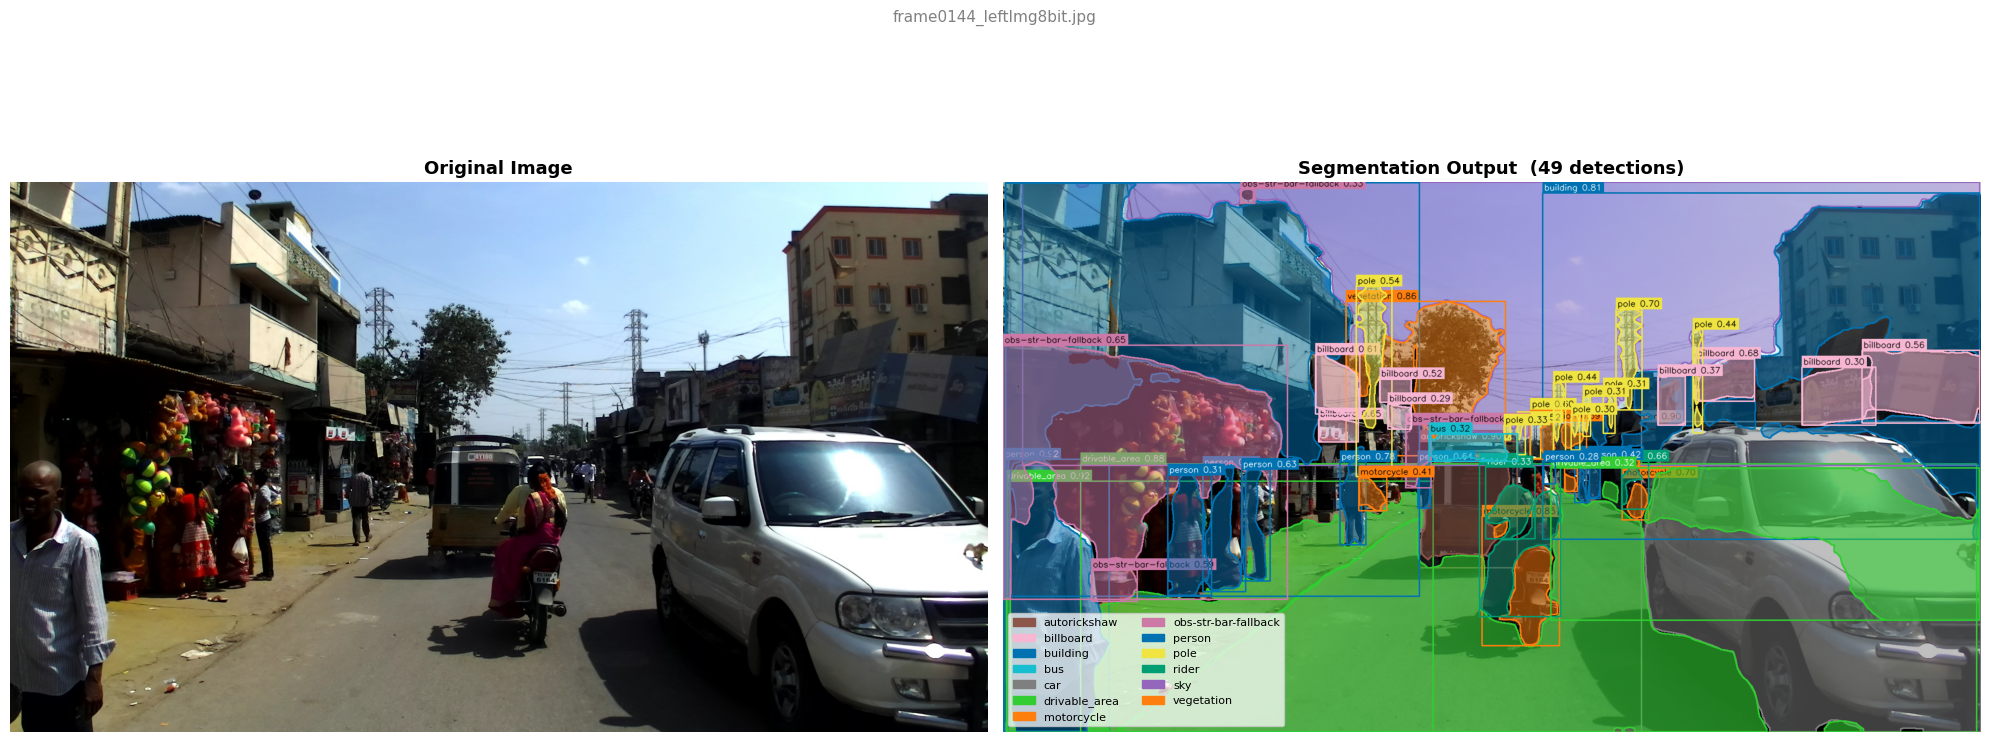

In [2]:
# ════════════════════════════════════════════════════════════════════════════
#  QUICK TEST — run inference on a single image and display inline
# ════════════════════════════════════════════════════════════════════════════
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2, numpy as np, torch
from ultralytics import YOLO

# ✏️ Set your test image path here
TEST_IMAGE   = r"D:\Detectron\idd20kII\idd20kII\leftImg8bit\val\272\frame0144_leftImg8bit.jpg"
#TEST_IMAGE = r"C:\Users\krris\Downloads\im2.jpg"
CONF_THRESH  = 0.25
IOU_THRESH   = 0.45
MASK_ALPHA   = 0.50

# ── Colour palette (BGR→RGB handled at display time) ─────────────────────────
DRIVABLE_NAME  = "drivable_area"
DRIVABLE_RGB   = (50, 205, 50)

_PALETTE_RGB = [
    (86,180,233),(230,159,0),(240,228,66),(204,121,167),(0,114,178),
    (213,94,0),(0,158,115),(255,127,14),(148,103,189),(140,86,75),
    (127,127,127),(188,189,34),(23,190,207),(31,119,180),(255,187,120),
    (174,199,232),(255,152,150),(197,176,213),(196,156,148),(247,182,210),
]

def get_rgb(class_id, class_name):
    if class_name == DRIVABLE_NAME:
        return DRIVABLE_RGB
    return _PALETTE_RGB[class_id % len(_PALETTE_RGB)]

# ── Load model ────────────────────────────────────────────────────────────────
inf_model = YOLO(r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936_ep404_ep100\weights\best.pt")   # uses BEST_WEIGHTS from training cell
names     = inf_model.names           # {id: name}

# ── Load image ────────────────────────────────────────────────────────────────
img_bgr = cv2.imread(TEST_IMAGE)
assert img_bgr is not None, f"Could not read image: {TEST_IMAGE}"
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

# ── Run inference ─────────────────────────────────────────────────────────────
results = inf_model.predict(
    source       = img_bgr,
    conf         = CONF_THRESH,
    iou          = IOU_THRESH,
    imgsz        = 640,
    device       = DEVICE,
    retina_masks = True,
    verbose      = False,
)
result = results[0]
boxes  = result.boxes
masks  = result.masks

print(f"Detections : {len(boxes) if boxes else 0}")

# ── Overlay masks on a copy of the image ─────────────────────────────────────
overlay = img_rgb.copy().astype(np.float32)

legend_entries = {}   # class_name → rgb colour (for legend)

if masks is not None and boxes is not None:
    for box, mask in zip(boxes, masks.data.cpu().numpy()):
        cls_id   = int(box.cls[0].item())
        cls_name = names.get(cls_id, f"cls_{cls_id}")
        conf     = float(box.conf[0].item())
        colour   = get_rgb(cls_id, cls_name)
        legend_entries[cls_name] = colour

        # Resize mask to original image size
        msk = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5

        # Fill mask with colour
        alpha = 0.60 if cls_name == DRIVABLE_NAME else MASK_ALPHA
        overlay[msk] = (
            overlay[msk] * (1 - alpha) +
            np.array(colour, dtype=np.float32) * alpha
        )

        # Draw contour
        contours, _ = cv2.findContours(
            msk.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        # contours are drawn on uint8 copy then merged
        overlay_u8 = overlay.astype(np.uint8)
        cv2.drawContours(overlay_u8, contours, -1, colour, 2)
        overlay = overlay_u8.astype(np.float32)

        # Draw bounding box + label
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        overlay_u8 = overlay.astype(np.uint8)
        cv2.rectangle(overlay_u8, (x1, y1), (x2, y2), colour, 2)
        label = f"{cls_name} {conf:.2f}"
        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(overlay_u8, (x1, max(0, y1-th-bl-4)), (x1+tw+6, y1), colour, -1)
        tc = (0,0,0) if sum(colour) > 380 else (255,255,255)
        cv2.putText(overlay_u8, label, (x1+3, y1-bl),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, tc, 1, cv2.LINE_AA)
        overlay = overlay_u8.astype(np.float32)

final = overlay.astype(np.uint8)

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(final)
axes[1].set_title(f"Segmentation Output  ({len(boxes) if boxes else 0} detections)", 
                  fontsize=13, fontweight="bold")
axes[1].axis("off")

# Legend
patches = [
    mpatches.Patch(color=np.array(rgb)/255, label=name)
    for name, rgb in sorted(legend_entries.items())
]
if patches:
    axes[1].legend(
        handles=patches, loc="lower left", fontsize=8,
        framealpha=0.75, ncol=2, bbox_to_anchor=(0, 0)
    )

plt.suptitle(TEST_IMAGE.split("\\")[-1], fontsize=11, color="gray")
plt.tight_layout()
plt.show()

# For videos

In [5]:
# ════════════════════════════════════════════════════════════════════════════
#  VIDEO INFERENCE — plays segmented output in a live OpenCV window
# ════════════════════════════════════════════════════════════════════════════
import cv2, numpy as np, time

# ✏️ Edit these
VIDEO_PATH  = r"C:\Users\krris\Downloads\YTDown.com_YouTube_Outer-Ring-Road-to-Whitefield-Bangalore-_Media_S7j75HsSnaw_003_360p_clips\clip_020.mp4"
CONF_THRESH = 0.45
IOU_THRESH  = 0.45
MASK_ALPHA  = 0.45

# ── Open video ────────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open: {VIDEO_PATH}"

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps   = cap.get(cv2.CAP_PROP_FPS) or 30
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Video: {W}x{H}  |  {total} frames  |  {fps:.1f} FPS")
print("Press  Q  in the window to quit early.\n")

frame_idx = 0
t_total   = 0.0
window    = "Segmented Output  [Q = quit]"
cv2.namedWindow(window, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window, min(W, 1280), min(H, 720))

while True:
    ret, frame_bgr = cap.read()
    if not ret:
        break

    t0 = time.time()

    # ── Inference ─────────────────────────────────────────────────────────────
    results = inf_model.predict(
        source       = frame_bgr,
        conf         = CONF_THRESH,
        iou          = IOU_THRESH,
        imgsz        = 320,
        device       = DEVICE,
        retina_masks = True,
        verbose      = False,
        half         = True,    # fp16 — fastest on RTX 4050
    )

    t_inf  = time.time() - t0
    t_total += t_inf
    frame_idx += 1

    result = results[0]
    boxes  = result.boxes
    masks  = result.masks

    # ── Overlay masks ─────────────────────────────────────────────────────────
    overlay = frame_bgr.copy().astype(np.float32)   # stay in BGR for cv2

    if masks is not None and boxes is not None:
        for box, mask in zip(boxes, masks.data.cpu().numpy()):
            cls_id   = int(box.cls[0].item())
            cls_name = names.get(cls_id, f"cls_{cls_id}")
            colour   = get_rgb(cls_id, cls_name)          # returns RGB tuple
            bgr      = (colour[2], colour[1], colour[0])  # flip to BGR for cv2

            msk   = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5
            alpha = 0.60 if cls_name == DRIVABLE_NAME else MASK_ALPHA
            overlay[msk] = (
                overlay[msk] * (1 - alpha) +
                np.array(bgr, dtype=np.float32) * alpha
            )

            overlay_u8 = overlay.astype(np.uint8)

            # Contour
            contours, _ = cv2.findContours(
                msk.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            cv2.drawContours(overlay_u8, contours, -1, bgr, 2)

            # Box + label
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf  = float(box.conf[0].item())
            label = f"{cls_name} {conf:.2f}"
            cv2.rectangle(overlay_u8, (x1, y1), (x2, y2), bgr, 2)
            (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(overlay_u8, (x1, max(0, y1-th-bl-4)), (x1+tw+6, y1), bgr, -1)
            tc = (0,0,0) if sum(bgr) > 380 else (255,255,255)
            cv2.putText(overlay_u8, label, (x1+3, y1-bl),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, tc, 1, cv2.LINE_AA)
            overlay = overlay_u8.astype(np.float32)

    final = overlay.astype(np.uint8)

    # ── FPS counter overlay ───────────────────────────────────────────────────
    avg_fps = frame_idx / t_total if t_total > 0 else 0
    cv2.putText(final,
                f"FPS: {1/t_inf:.1f}  |  avg: {avg_fps:.1f}  |  frame: {frame_idx}/{total}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 200), 2, cv2.LINE_AA)

    # ── Show in window ────────────────────────────────────────────────────────
    cv2.imshow(window, final)

    # Wait just 1ms — keeps window responsive, maximises FPS
    if cv2.waitKey(1) & 0xFF == ord("q"):
        print("Stopped by user.")
        break

cap.release()
cv2.destroyAllWindows()

avg_ms = (t_total / frame_idx * 1000) if frame_idx else 0
print(f"\n✅ Done — {frame_idx} frames  |  avg {avg_ms:.1f} ms/frame  |  avg {1000/avg_ms:.1f} FPS")

Video: 640x360  |  1125 frames  |  25.0 FPS
Press  Q  in the window to quit early.


✅ Done — 1125 frames  |  avg 34.5 ms/frame  |  avg 29.0 FPS
